# 课程总结：深层网络训练诊断与 BatchNorm

本节课核心内容：

1. **自定义层实现**：从零实现 `Linear`、`BatchNorm1d`、`Tanh` 层，理解前向/反向传播细节。
2. **深层网络构建**：搭建 6 层 MLP，结合 BatchNorm 与 Tanh 激活，用于名字生成（makemore）。
3. **权重初始化**：对 Tanh 层使用 `5/3` 的 Kaiming 初始化修正因子，防止激活在深层网络中饱和或爆炸。
4. **训练监控**：
   - **激活分布**：检查各层输出是否落入 Tanh 饱和区（`abs > 0.97`）。
   - **梯度分布**：观察反向传播梯度在各层的健康程度。
   - **权重梯度比**：监控 `grad.std / weight.std`，确保更新幅度合理。
   - **更新数据比 (update-to-data ratio)**：追踪 `lr * grad.std / weight.std`，理想值约在 `1e-3` 量级。
5. **学习率衰减**：前 10000 步使用 `lr=0.1`，之后降至 `0.01`。

> 目标：通过可视化诊断工具，理解深层网络训练中的数值稳定性问题，掌握 BatchNorm 和良好初始化对训练动态的关键作用。

In [185]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
g = torch.Generator().manual_seed(0)
class Linear:
    def __init__(self, f_in, f_out, bias = True):
        self.f_in = f_in
        self.f_out = f_out
        self.weight = torch.randn((f_in, f_out), generator=g) / f_in ** 0.5
        self.bias = torch.zeros(size=(f_out,)) if bias else None
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight] + [self.bias] if self.bias is not None else [self.weight]
class BatchNorm1d:
    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.dim = dim
        self.eps = eps
        self.momentum = momentum
        
        self.training = True

        self.gamma = torch.ones(self.dim)
        self.beta = torch.zeros(self.dim)

        self.running_mean = torch.zeros(dim)
        self.running_var  = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(dim = 0, keepdim = True)
            xvar = x.var(dim = 0, keepdim = True)
        else: 
            xmean = self.running_mean 
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []
    

In [186]:
nemb = 10
n_hidden = 100
block_size = 3
vocab_size = 27
C = torch.randn(size=(27,nemb), generator= g)

layers = [
    Linear(block_size * nemb, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),BatchNorm1d(n_hidden),  Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
]

with torch.no_grad():
    layers[-1].weight *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum([p.nelement() for p in parameters]))
for p in parameters:
    p.requires_grad = True

47497


In [187]:
words = open('./data/names.txt', mode='r').read().splitlines()
chars = list(sorted(set(''.join(words))))
stoi = {k:v+1 for v, k in enumerate(chars)}
stoi['.'] = 0
itos = {k:v for v,k in stoi.items()}
X, Y = [], []
def build_dataset(words):
    for w in words:
        context = [0] * 3
        chs = w + '.'
        for i in chs:
            ix = stoi[i]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)
import numpy as np
np.random.seed(42)
words = np.random.permutation(words)

n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [188]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], size=(batch_size,), generator= g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    # print(emb.shape)
    x = emb.view(emb.shape[0],-1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if i < 10000 else 0.01

    for p in parameters:
        p.data -= lr * p.grad

    if i % 1000 ==0 :
        print(loss.item())

    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])
    if i >= 1000:
        break


3.297145366668701
2.439319610595703


layer 2 (      Tanh): mean +0.00, std 0.63, saturated: 2.84%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.34%
layer 8 (      Tanh): mean +0.00, std 0.64, saturated: 2.19%
layer 11 (      Tanh): mean +0.00, std 0.64, saturated: 2.44%
layer 14 (      Tanh): mean -0.02, std 0.65, saturated: 2.31%


Text(0.5, 1.0, 'activation distribution')

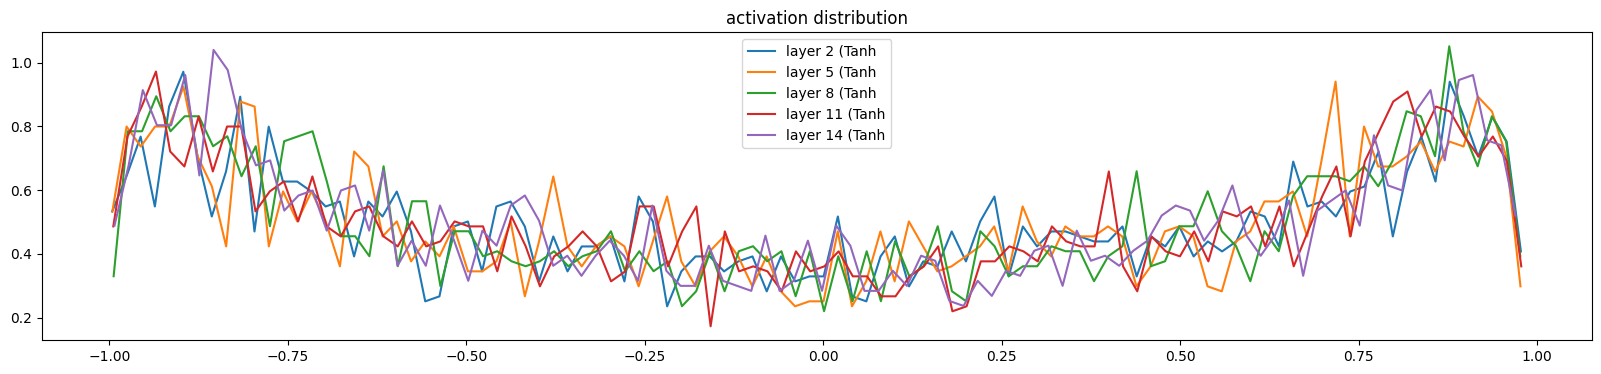

In [189]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh ):
    t = layer.out ### （32，100）
    # print(t.shape)
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

torch.Size([32, 100])
layer 2 (      Tanh): mean +0.000000, std 3.575397e-03
torch.Size([32, 100])
layer 5 (      Tanh): mean +0.000000, std 3.091366e-03
torch.Size([32, 100])
layer 8 (      Tanh): mean +0.000000, std 2.820027e-03
torch.Size([32, 100])
layer 11 (      Tanh): mean +0.000000, std 2.486338e-03
torch.Size([32, 100])
layer 14 (      Tanh): mean +0.000002, std 2.013751e-03


Text(0.5, 1.0, 'gradient distribution')

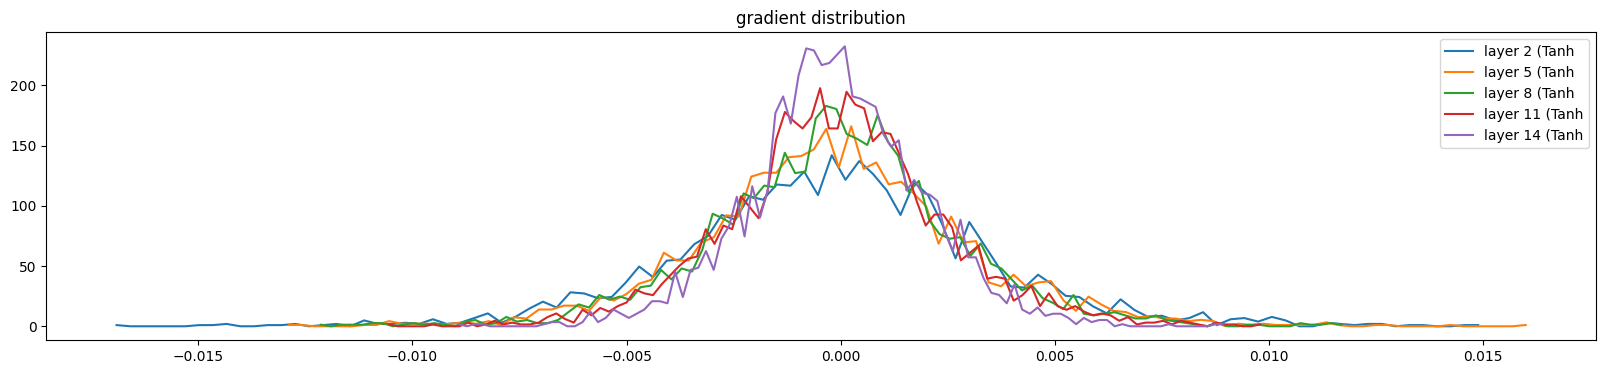

In [190]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad ### round L / round out
    # t = (1 - layer.out**2)
    print(t.shape)
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 1.096956e-02 | grad:data ratio 1.181075e-02
weight  (30, 100) | mean -0.000013 | std 9.406969e-03 | grad:data ratio 3.078886e-02
weight (100, 100) | mean +0.000054 | std 7.051588e-03 | grad:data ratio 4.198890e-02
weight (100, 100) | mean -0.000042 | std 5.954453e-03 | grad:data ratio 3.522941e-02
weight (100, 100) | mean +0.000023 | std 5.371826e-03 | grad:data ratio 3.195665e-02
weight (100, 100) | mean -0.000059 | std 4.347688e-03 | grad:data ratio 2.625553e-02
weight  (100, 27) | mean -0.000000 | std 2.131590e-02 | grad:data ratio 3.442297e-01


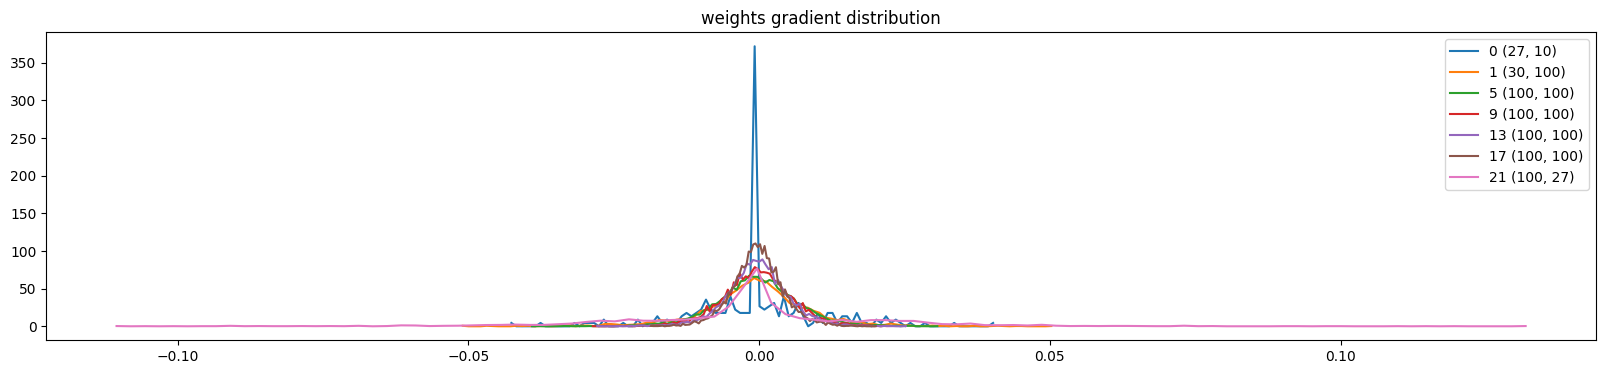

In [191]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

In [192]:
print(ud)

[[-3.7585766315460205, -3.3469974994659424, 0.0, -5.02190687257098e-06, 0.0, -3.1015119552612305, 0.0, 1.894811612146441e-05, 0.0, -3.1778106689453125, 0.0, 1.4858291251584888e-05, 0.0, -3.212357759475708, 0.0, -1.0147417924599722e-05, 0.0, -3.2425146102905273, 0.0, -8.205929589166772e-06, 0.0, -0.5930495858192444, 0.0], [-3.8940048217773438, -3.3957407474517822, -0.315154105424881, -0.23820245265960693, -0.17676565051078796, -3.1440162658691406, -0.22053924202919006, -0.1578587144613266, -0.0977044627070427, -3.171501398086548, -0.18494144082069397, -0.19727756083011627, -0.23002299666404724, -3.22963285446167, -0.163082093000412, -0.20496144890785217, -0.15832437574863434, -3.2934823036193848, -0.1365758627653122, -0.1955893337726593, -0.1725429892539978, -0.6835637092590332, -0.17311984300613403], [-3.8068454265594482, -3.34266996383667, -0.12510989606380463, -0.28267809748649597, -0.20884473621845245, -3.121720314025879, -0.1758001297712326, -0.22385160624980927, -0.212988242506980

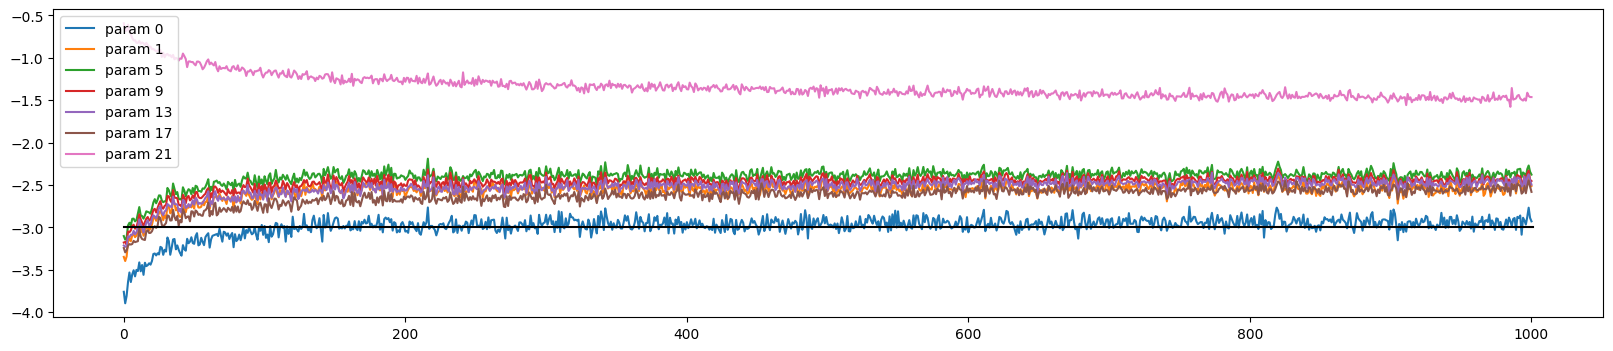

In [193]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);